# 08 — Harsh learnability filter on the AUC target (top-5 drugs)

Picks the **few** CTRPv2 drugs where a cross-cell-line signal could plausibly exist at all, so the
PCA-vs-scGPT question can be asked on drugs that are not hopeless by construction. Same idea as the
learnability table in `04_drug_coverage.ipynb` (**coverage × response spread**), but adapted to the
`auc_z` target (13.07.2026) and made **much stricter** — 545 → **5** drugs.

**Why the old formula cannot be reused as-is.** `04` scored drugs with
`learnability = resp_std × cov_frac`, reading `resp_std` straight from the target matrix. On the new
target that is **degenerate**: `auc_z` is z-scored *per drug*, so every drug has a response std of
exactly **1.0** and the ranking collapses — all 545 drugs tie.

**The fix:** measure spread on the **raw `auc` scale**, which is recoverable exactly, since the
targets file stores the per-drug de-standardization constants:

```
auc = auc_z * uns["ctrp_score_scale"] + uns["ctrp_score_center"]
```

(`ctrp_score_scale` *is* the per-drug std of `auc` across cell lines, i.e. precisely the `resp_std`
the old formula wanted.) `auc` is the grid-normalized area under the fitted dose-response curve — a
viability-like number, low = the drug kills that line, high = the line survives — so a single spread
threshold is meaningful across drugs, exactly as it was for `cpd_avg_pv`.

**Why stricter.** `04` established that a loose `cov ≥ 100 & std ≥ 0.05` filter keeps **439/545** —
it removes almost nothing, and the model still fails to rank cell lines. So this notebook adds the
condition that was missing: a drug must show **genuinely differential response** — a real population
of killed lines *and* a real population of surviving ones. A drug that is uniformly inert (or
uniformly toxic) has no cross-line ranking to learn, however well covered it is.

In [1]:
import sys
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from scripts.preprocessing.layout import PipelinePaths

OUT = Path('outputs'); OUT.mkdir(exist_ok=True)

SCORE, VARIANT = 'auc_z', 'hvg5000'
N_KEEP = 5                      # how many drugs to hand to training

paths = PipelinePaths.build(None, VARIANT, SCORE)
a = ad.read_h5ad(paths.targets_h5ad, backed='r')   # backed: .X stays on disk, we only touch obsm/uns
print(paths.targets_h5ad.name, '| score =', a.uns['ctrp_score'])

SCP542_CCLE_scGPT_human_embeddings_with_targets_auc_z.h5ad | score = auc_z


## 1. Collapse to the real (cell line × drug) measurements

The label is bulk: constant within a cell line, broadcast to all its cells. Anything per-drug must
therefore be computed on the **line-level** matrix, otherwise cell-rich lines get over-counted.

In [2]:
Y = np.asarray(a.obsm['Y_ctrp'], dtype=float)     # auc_z, NaN where unscreened
M = np.asarray(a.obsm['M_ctrp'], dtype=bool)
center = np.asarray(a.uns['ctrp_score_center'], dtype=float)   # per-drug mean of auc
scale = np.asarray(a.uns['ctrp_score_scale'], dtype=float)     # per-drug std  of auc
drugs = list(a.uns['ctrp_drugs'])
K = len(drugs)

lines = a.obs['Cell_line'].astype(str).to_numpy()
uniq = np.unique(lines)

# per-line value = mean over that line's observed cells (they are all identical anyway)
Z = np.full((len(uniq), K), np.nan)
for i, ln in enumerate(uniq):
    idx = np.flatnonzero(lines == ln)
    m = M[idx]
    has, cnt = m.any(0), m.sum(0)
    s = np.where(m, Y[idx], 0.0).sum(0)
    Z[i, has] = s[has] / cnt[has]

A = Z * scale + center                       # <- back to raw auc units
n_lines_tot = int(np.isfinite(Z).any(1).sum())

print(f'{len(uniq)} cell lines x {K} drugs; {n_lines_tot} lines carry >=1 label')
print(f'std of auc_z per drug : median {np.nanmedian(np.nanstd(Z, 0)):.4f}  <- degenerate by construction')
print(f'std of auc   per drug : median {np.median(scale):.4f}  (min {scale.min():.3f}, max {scale.max():.3f})')
print(f'auc overall: median {np.nanmedian(A):.3f}, p05 {np.nanpercentile(A, 5):.3f}, p95 {np.nanpercentile(A, 95):.3f}')

198 cell lines x 545 drugs; 180 lines carry >=1 label
std of auc_z per drug : median 1.0000  <- degenerate by construction
std of auc   per drug : median 0.1092  (min 0.034, max 0.302)
auc overall: median 0.877, p05 0.536, p95 1.071


## 2. Per-drug learnability features

Same two factors as `04` (**coverage**, **spread**), plus the differential-response counts that make
the filter bite. `auc` is viability-like, so:

- `n_sens` — lines the drug actually **kills** (`auc ≤ 0.5`)
- `n_res`  — lines that **survive** it (`auc ≥ 0.8`)

A learnable drug needs **both** to be substantial: that is what a cross-line ranking *is*. `dyn_range`
(p95 − p05) is the same idea as a robust, outlier-insensitive continuous measure.

In [3]:
SENS_MAX, RES_MIN = 0.5, 0.8      # auc thresholds: killed / survived

cov = np.isfinite(A).sum(0)
p05 = np.nanpercentile(A, 5, axis=0)
p95 = np.nanpercentile(A, 95, axis=0)

df = pd.DataFrame({
    'drug': drugs,
    'n_lines': cov,
    'cov_frac': cov / n_lines_tot,
    'auc_mean': np.nanmean(A, axis=0),
    'auc_std': scale,                          # == per-drug std of auc across lines
    'dyn_range': p95 - p05,
    'n_sens': (A <= SENS_MAX).sum(0),
    'n_res': (A >= RES_MIN).sum(0),
})

# The 04 score, now on the auc scale where it is not degenerate: spread x coverage.
df['learnability'] = df['auc_std'] * df['cov_frac']

print(df[['auc_std', 'dyn_range', 'n_sens', 'n_res']].describe().loc[['50%', '75%', 'max']].round(3).to_string())

     auc_std  dyn_range  n_sens  n_res
50%    0.109      0.306     0.0  108.0
75%    0.144      0.428     1.0  159.0
max    0.302      1.016   151.0  176.0


## 3. The harsh gates → 5 drugs

Every gate is set **well above the median** of its distribution — that is the whole point, the loose
version keeps 439/545 and teaches us nothing.

| Gate | Threshold | Median over 545 |
|---|---|---|
| coverage | ≥ 95 % of the 180 lines | 95 % |
| spread on auc | `auc_std ≥ 0.15` | 0.109 |
| dynamic range | `p95 − p05 ≥ 0.40` | 0.306 |
| killed lines | `n_sens ≥ 20` | — |
| surviving lines | `n_res ≥ 20` | — |

The last two are the ones that do the real work: they demand the drug **separate** the panel.

In [4]:
COV_MIN, STD_MIN, DYN_MIN, N_SENS_MIN, N_RES_MIN = 0.95, 0.15, 0.40, 20, 20

gates = {
    'coverage >= 95%': df['cov_frac'] >= COV_MIN,
    'auc_std >= 0.15': df['auc_std'] >= STD_MIN,
    'dyn_range >= 0.40': df['dyn_range'] >= DYN_MIN,
    f'n_sens >= {N_SENS_MIN} (killed)': df['n_sens'] >= N_SENS_MIN,
    f'n_res >= {N_RES_MIN} (survived)': df['n_res'] >= N_RES_MIN,
}
for name, g in gates.items():
    print(f'  {name:<28} passes alone: {int(g.sum()):>3} / {K}')

df['learnable_strict'] = np.logical_and.reduce(list(gates.values()))
print(f'\npassing ALL gates: {int(df["learnable_strict"].sum())} / {K}')

top = (df[df['learnable_strict']]
       .sort_values('learnability', ascending=False)
       .head(N_KEEP)
       .reset_index(drop=True))
top.insert(0, 'rank', top.index + 1)
print()
print(top.round(3).to_string(index=False))

KEEP = top['drug'].tolist()

  coverage >= 95%              passes alone: 284 / 545
  auc_std >= 0.15              passes alone: 113 / 545
  dyn_range >= 0.40            passes alone: 165 / 545
  n_sens >= 20 (killed)        passes alone:  47 / 545
  n_res >= 20 (survived)       passes alone: 493 / 545

passing ALL gates: 6 / 545

 rank        drug  n_lines  cov_frac  auc_mean  auc_std  dyn_range  n_sens  n_res  learnability  learnable_strict
    1 1s,3r-rsl-3      173     0.961     0.553    0.194      0.619      75     21         0.186              True
    2     kx2-391      175     0.972     0.655    0.179      0.589      34     33         0.174              True
    3    cay10618      174     0.967     0.678    0.177      0.493      21     33         0.171              True
    4       ml162      176     0.978     0.628    0.156      0.496      48     27         0.153              True
    5   dasatinib      177     0.983     0.631    0.155      0.468      35     27         0.153              True


## 4. What the 5 look like vs. the other 540

Left: the `04` coverage-vs-spread scatter, now on the auc scale, with the survivors marked — they sit
in the far top-right corner. Right: their response bands across cell lines. Unlike a typical CTRPv2
drug (whose lines are squeezed into a narrow high band), these actually **span** the panel from killed
to untouched, which is the only situation in which "rank the cell lines" is a well-posed task.

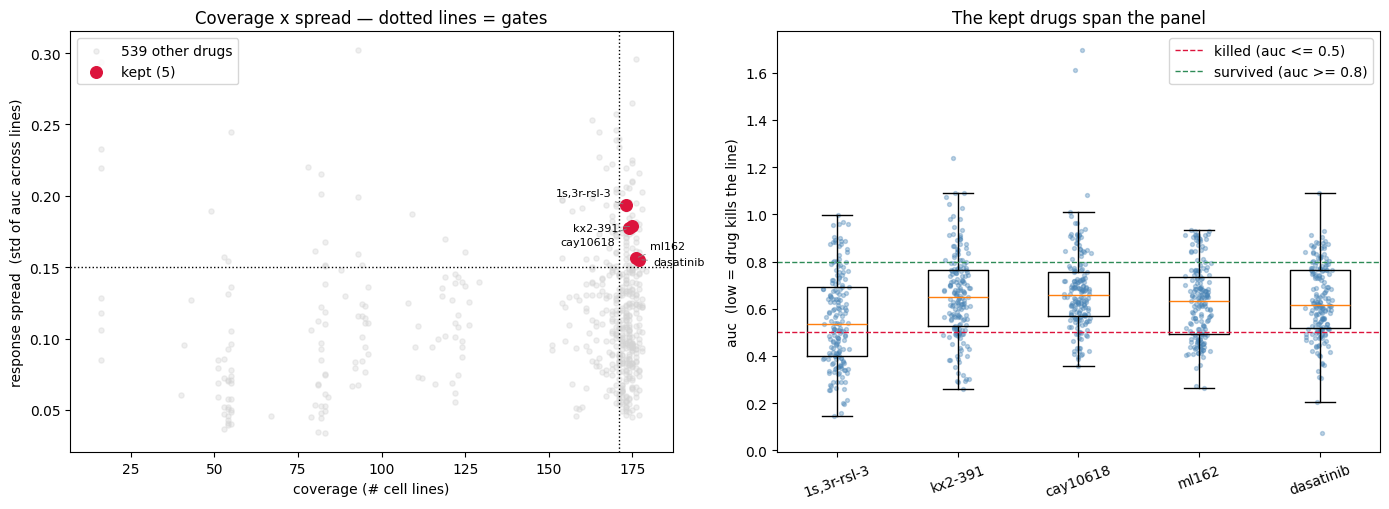

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))

rest = ~df['learnable_strict']
ax[0].scatter(df.loc[rest, 'n_lines'], df.loc[rest, 'auc_std'], s=14, alpha=0.35,
              color='lightgray', label=f'{int(rest.sum())} other drugs')
sel = df['drug'].isin(KEEP)
ax[0].scatter(df.loc[sel, 'n_lines'], df.loc[sel, 'auc_std'], s=70, color='crimson',
              zorder=3, label=f'kept ({len(KEEP)})')
ax[0].axhline(STD_MIN, color='k', ls=':', lw=1)
ax[0].axvline(COV_MIN * n_lines_tot, color='k', ls=':', lw=1)
offsets = [(-10, 6), (-10, -3), (-10, -12), (10, 7), (10, -4)]   # hand-placed: the 5 sit close together
for (_, r), off in zip(df[sel].sort_values('auc_std', ascending=False).iterrows(), offsets):
    ax[0].annotate(r['drug'], (r['n_lines'], r['auc_std']), fontsize=8, xytext=off,
                   textcoords='offset points', ha='right' if off[0] < 0 else 'left',
                   arrowprops=dict(arrowstyle='-', lw=0.6, color='gray'))
ax[0].set_xlabel('coverage (# cell lines)')
ax[0].set_ylabel('response spread  (std of auc across lines)')
ax[0].set_title('Coverage x spread — dotted lines = gates')
ax[0].legend(loc='upper left')

idx = [drugs.index(d) for d in KEEP]
data = [A[np.isfinite(A[:, k]), k] for k in idx]
ax[1].boxplot(data, vert=True, tick_labels=KEEP, showfliers=False)
for i, v in enumerate(data, start=1):
    ax[1].scatter(np.random.default_rng(0).normal(i, 0.05, len(v)), v, s=8, alpha=0.35, color='steelblue')
ax[1].axhline(SENS_MAX, color='crimson', ls='--', lw=1, label=f'killed (auc <= {SENS_MAX})')
ax[1].axhline(RES_MIN, color='seagreen', ls='--', lw=1, label=f'survived (auc >= {RES_MIN})')
ax[1].set_ylabel('auc  (low = drug kills the line)')
ax[1].set_title('The kept drugs span the panel')
ax[1].tick_params(axis='x', rotation=20)
ax[1].legend()

plt.tight_layout()
plt.savefig(OUT / 'learnability' / 'learnability_filter_auc.png', dpi=200)
plt.show()

## 5. Save + the training command

The full 545-drug ranking goes to `outputs/learnability/ctrp_drug_learnability_auc.csv` (the auc-scale counterpart
of `data/ctrp_drug_learnability.csv`, which was built on the legacy `mean_pv` target). The 5 kept drugs are
printed as a ready-to-paste `--drugs` argument.

In [6]:
full = (df.sort_values('learnability', ascending=False).reset_index(drop=True).round(5))
full.insert(0, 'rank', full.index + 1)
full.to_csv(OUT / 'learnability' / 'ctrp_drug_learnability_auc.csv', index=False)
print(f'saved {OUT / "04_learnability" / "ctrp_drug_learnability_auc.csv"}  ({len(full)} drugs, '
      f'{int(full["learnable_strict"].sum())} pass the strict gates)')

drug_args = ' '.join(f'"{d}"' if ' ' in d else d for d in KEEP)
print('\nTrain PCA vs scGPT on the learnable subset:\n')
for rep in ('X_scGPT', 'X_pca'):
    print(f'  uv run scripts/training/train_multitask.py --variant {VARIANT} --score {SCORE} \\\n'
          f'      --use-rep {rep} --drugs {drug_args}\n')

saved outputs/ctrp_drug_learnability_auc.csv  (545 drugs, 6 pass the strict gates)

Train PCA vs scGPT on the learnable subset:

  uv run scripts/training/train_multitask.py --variant hvg5000 --score auc_z \
      --use-rep X_scGPT --drugs 1s,3r-rsl-3 kx2-391 cay10618 ml162 dasatinib

  uv run scripts/training/train_multitask.py --variant hvg5000 --score auc_z \
      --use-rep X_pca --drugs 1s,3r-rsl-3 kx2-391 cay10618 ml162 dasatinib



## Read-out

**5 of 545 drugs survive** (6 pass the gates; the top 5 by `learnability = auc_std × cov_frac` are
kept). They are not a random sample — the list is dominated by compounds with a known
**differential** mechanism, which is a sanity check that the filter selects for biology rather than
noise:

- **1s,3r-RSL-3** and **ML162** — GPX4 inhibitors (ferroptosis). Sensitivity is known to track a
  cell's lipid-peroxidation / redox state, which is a *transcriptional* state — the best possible
  case for this project's hypothesis.
- **dasatinib** — SRC/ABL TKI, the textbook example of a drug that kills only the lines addicted to
  its target.
- **KX2-391** (SRC/tubulin) and **CAY10618** (NAMPT inhibitor) — likewise target-driven.

**Caveat, stated up front:** these gates were chosen *on the full panel*, val/test lines included, so
the 5 drugs are selected with knowledge of the held-out labels. That is acceptable for a
**best-case diagnostic** — the question being asked is "does *any* learnable signal exist here?", not
"what is the unbiased generalization error". If the answer turns out to be yes, the selection has to
be redone train-only before the number means anything.

Next: train PCA vs scGPT on exactly these 5 heads (command above) and check the per-drug Spearman
across held-out lines, which is the metric that mattered in `07` §3 — absolute MSE will hover near
1.0 by construction on a z-scored target.